In [3]:

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from matplotlib import cm
from nonlinear_approximator import (
    activations,
    inference,
    model,
    params,
    training, 
)
from scipy.stats import qmc

%matplotlib inline



sample.shape=(2, 1), (neurons).shape=(2, 1000), activations.shape=(2, 100, 1000)
sample.shape=(2, 1), (neurons).shape=(2, 1000), activations.shape=(2, 100, 1000)


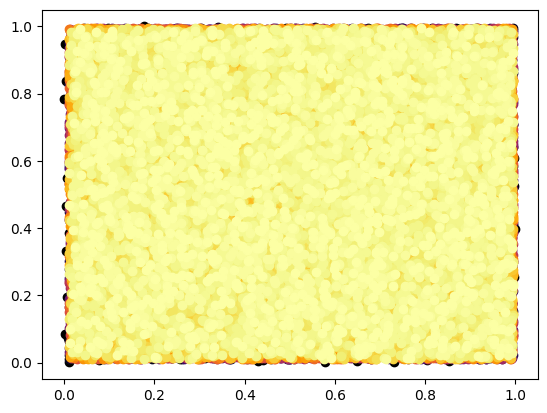

In [5]:
config = params.RegressionParams(
    width=1000,
    depth=100,
    input_dimension=2,
    transform_type=activations.TransformType.TENT,
    transform_params= params.TentParams(mu=1.99),
    output_dimension=1,
)

neurons = np.random.normal(loc=0, scale=1, size=(config.input_dimension, config.width))
neurons = 0.5 * neurons / np.linalg.norm(neurons, axis=0)
neurons = np.asarray(neurons)

def gen_neurons(dimension, number):
    sampler = qmc.LatinHypercube(d=dimension)
    sample = sampler.random(n=number) 
    return sample

def tent(x, mu=1.99):

    # return np.exp(-900 * np.square(x)) + -0.06045
    return mu * np.minimum(x, 1 - x)

def compute_activations(neurons, input_x, config):
    num_samples, dim_input = input_x.shape
    # neurons have dim_input x 3config.width shape
    activations = np.zeros((num_samples, config.depth, config.width))
    for idx_sample in range(num_samples):
        for idx_layer in range(config.depth):
            if idx_layer == 0:
                sample =  np.expand_dims(input_x[idx_sample, :], axis=-1)
                print(f'{sample.shape=}, {(neurons).shape=}, {activations.shape=}')
                activations[idx_sample, idx_layer, :] = 1 - np.linalg.norm(neurons - sample,axis=0)/np.sqrt(dim_input)
            else:
                activations[idx_sample, idx_layer, :] = tent(
                    activations[idx_sample, idx_layer - 1, :]
                )
    return activations

neurons = gen_neurons(2, config.width).T
disp_layers = config.depth # min(8, config.depth + 1)

colors = plt.get_cmap("inferno", disp_layers + 1)
activations_identity = compute_activations(
    neurons, np.asarray(np.eye(2)), config
)

plt.scatter(neurons[0, :], neurons[1, :], color="black")
for idx_layer in range(1, disp_layers):
    plt.scatter(
        activations_identity[0, idx_layer, :], #* neurons[0, :],
        activations_identity[1, idx_layer, :],# * neurons[1, :],
        label=f"Pass {idx_layer + 1}",
        color=colors(idx_layer + 1),
    )

plt.show()

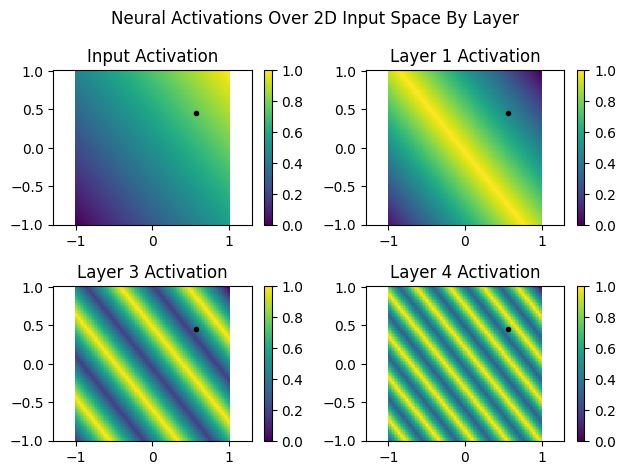

In [34]:
# evaluate the  activation of a given neuron over a 2d plane. 
# single neuron over 1,3
def dist(x, y):
    return np.linalg.norm(x - y, axis=0)

def acts(neurons, layer, config):
    xs = np.linspace(-1, 1, num=100)
    X, Y = np.meshgrid(xs, xs)
    Z = np.zeros_like(X)
    for idx_neuron in range(neurons.shape[1]):    
        acts_neuron =  ((X+1)/2 * neurons[0, idx_neuron] + (Y+1)/2 *neurons[1, idx_neuron])
                 
        # acts_neuron = np.where(acts_neuron > 0, acts_neuron, 0)
        
        XY = np.stack([X,Y])
        XY_neuron = np.zeros_like(XY)
        XY_neuron[0,:,:] = neurons[0,idx_neuron]
        XY_neuron[1,:,:] = neurons[1,idx_neuron]
        # acts_neuron = 1 - dist(XY, XY_neuron)/ np.sqrt(2)

        for j in range(layer):
            acts_neuron = config.transform_type.value(acts_neuron, config.transform_params)
        if 'Z' not in locals():
            Z = acts_neuron
        else:
            Z += acts_neuron
    return X, Y, Z

xs = np.linspace(-1, 1, num=10000)
layer = 0
plt.figure('input')
plt.clf()
# Neuron count 1
neuron_count = 1
neurons = gen_neurons(2, neuron_count).T
plt.suptitle("Neural Activations Over 2D Input Space By Layer")
for idx, layer in enumerate([0, 1, 3 , 4]):
    plt.subplot(2,2,idx+1)
    plt.axis('equal')
    X,Y,Z = acts(neurons[:, 0:neuron_count], layer, config)
    c = plt.pcolormesh(X,Y, Z)
    plt.scatter(neurons[0,0:neuron_count], neurons[1,0:neuron_count], c='black', marker='.') 
    if idx == 0:
        plt.title("Input Activation")
    else: 
        plt.title(f"Layer {layer} Activation")
    plt.colorbar()
    plt.axis('equal')


# plt.subplot(2,2,2)
# X,Y,Z = acts(neurons[:, 0:neuron_count], 1, config)
# c = plt.pcolormesh(X,Y, Z)
# plt.scatter(neurons[0,0:neuron_count], neurons[1,0:neuron_count], c='black', marker='.') 
# plt.title("Layer 1 Activation")
# plt.colorbar()
# plt.axis('equal')

# plt.subplot(2,2,3)
# X,Y,Z = acts(neurons[:, 0:neuron_count], 2, config)
# c = plt.pcolormesh(X,Y, Z)
# plt.scatter(neurons[0,0:neuron_count], neurons[1,0:neuron_count], c='black', marker='.') 
# plt.title("Layer 2 Activation")
# plt.colorbar()
# plt.axis('equal')

# plt.subplot(2,2,4)
# X,Y,Z = acts(neurons[:, 0:neuron_count], 3, config)
# c = plt.pcolormesh(X,Y, Z)
# plt.scatter(neurons[0,0:neuron_count], neurons[1,0:neuron_count], c='black', marker='.') 
# plt.title("Layer 3 Activation")
# plt.colorbar()
# plt.axis('equal')
plt.gcf().tight_layout()

c.set_zorder(0)
plt.show()

# # neuron count 100 
# neuron_count =  10**4
# neurons = gen_neurons(2, neuron_count).T
# plt.figure('input2')
# plt.suptitle("Neural Activations Over 2D Input Space By Layer")
# plt.subplot(2,2,1)
# plt.axis('equal')
# X,Y,Z = acts(neurons[:, :], 0, config)
# c = plt.pcolormesh(X,Y, Z)
# plt.scatter(neurons[0,0:neuron_count], neurons[1,0:neuron_count], c='black', marker='.', alpha=.2) 
# plt.title("Input Activation")
# plt.colorbar()

# plt.subplot(2,2,2)
# X,Y,Z = acts(neurons[:, :], 1, config)
# c = plt.pcolormesh(X,Y, Z)
# plt.scatter(neurons[0,:], neurons[1,:], c='black', marker='.', alpha=.2) 
# plt.title("Layer 1 Activation")
# plt.colorbar()
# plt.axis('equal')

# plt.subplot(2,2,3)
# X,Y,Z = acts(neurons[:, :], 2, config)
# c = plt.pcolormesh(X,Y, Z)
# plt.scatter(neurons[0,:], neurons[1,:], c='black', marker='.', alpha=.2) 
# plt.title("Layer 2 Activation")
# plt.colorbar()
# plt.axis('equal')

# plt.subplot(2,2,4)
# X,Y,Z = acts(neurons[:, :], 3, config)
# c = plt.pcolormesh(X,Y, Z)
# plt.scatter(neurons[0,:], neurons[1,:], c='black', marker='.',alpha=.02) 
# plt.title("Layer 3 Activation")
# plt.colorbar()
# plt.axis('equal')
# plt.gcf().tight_layout()


# plt.gcf().tight_layout()

# c.set_zorder(0)
# plt.show()

In [36]:
XY.shape

(2, 100, 100)